In [19]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, RocCurveDisplay
)

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
df = pd.read_csv('data/S06-hw-dataset-01.csv')

In [5]:
print(df.head())

   id     num01     num02     num03     num04     num05     num06     num07  \
0   1 -0.946058 -0.070313  1.824445 -2.754422  0.808865 -0.111094 -0.268950   
1   2 -2.484027  0.739378  1.596908 -2.586479 -0.033225 -3.054412 -4.706908   
2   3  1.522629  7.159635 -0.564903 -4.493110  1.623610  5.450187 -0.974595   
3   4  0.463373 -1.073908  1.752813  0.362786  2.790872  4.082385  0.322283   
4   5  3.188390 -4.701692 -0.689918 -0.448995  0.373821 -3.275363 -1.760931   

      num08     num09  ...     num20     num21     num22     num23     num24  \
0 -3.078210  0.801275  ... -1.616515 -1.989464  1.407390 -0.218362  2.016052   
1 -9.795169  0.145911  ... -1.727040 -0.583997  1.136761  0.285978 -0.310879   
2 -5.189589  1.600591  ...  0.524408  2.022430  1.278358 -0.850547  0.847457   
3  3.390984 -0.033929  ...  2.399834 -1.431576 -0.746987  0.049639  2.414689   
4  0.923689  0.537345  ... -2.183407 -2.896590  2.440343 -1.097168  1.457323   

   cat_contract  cat_region  cat_payment  te

In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             12000 non-null  int64  
 1   num01          12000 non-null  float64
 2   num02          12000 non-null  float64
 3   num03          12000 non-null  float64
 4   num04          12000 non-null  float64
 5   num05          12000 non-null  float64
 6   num06          12000 non-null  float64
 7   num07          12000 non-null  float64
 8   num08          12000 non-null  float64
 9   num09          12000 non-null  float64
 10  num10          12000 non-null  float64
 11  num11          12000 non-null  float64
 12  num12          12000 non-null  float64
 13  num13          12000 non-null  float64
 14  num14          12000 non-null  float64
 15  num15          12000 non-null  float64
 16  num16          12000 non-null  float64
 17  num17          12000 non-null  float64
 18  num18 

In [15]:
print(df.describe())

                id         num01         num02         num03         num04  \
count  12000.00000  12000.000000  12000.000000  12000.000000  12000.000000   
mean    6000.50000      0.013705     -0.005278     -0.002357      0.038404   
std     3464.24595      2.096534      3.544498      1.004417      2.087318   
min        1.00000     -8.155181    -14.605579     -4.374043     -7.753301   
25%     3000.75000     -1.423844     -2.303772     -0.685618     -1.374579   
50%     6000.50000     -0.047565      0.053348     -0.009186      0.038766   
75%     9000.25000      1.422676      2.335937      0.671441      1.484417   
max    12000.00000      8.610863     16.299709      3.651692      7.571965   

              num05         num06         num07         num08         num09  \
count  12000.000000  12000.000000  12000.000000  12000.000000  12000.000000   
mean      -0.006301     -0.865297     -0.702877     -0.290694     -0.008154   
std        1.007329      3.888966      1.989513      3.45598

In [16]:
print(df.isnull().sum())

id               0
num01            0
num02            0
num03            0
num04            0
num05            0
num06            0
num07            0
num08            0
num09            0
num10            0
num11            0
num12            0
num13            0
num14            0
num15            0
num16            0
num17            0
num18            0
num19            0
num20            0
num21            0
num22            0
num23            0
num24            0
cat_contract     0
cat_region       0
cat_payment      0
tenure_months    0
target           0
dtype: int64


In [7]:
target_distribution = df['target'].value_counts(normalize=True)
print(target_distribution)

target
0    0.676583
1    0.323417
Name: proportion, dtype: float64


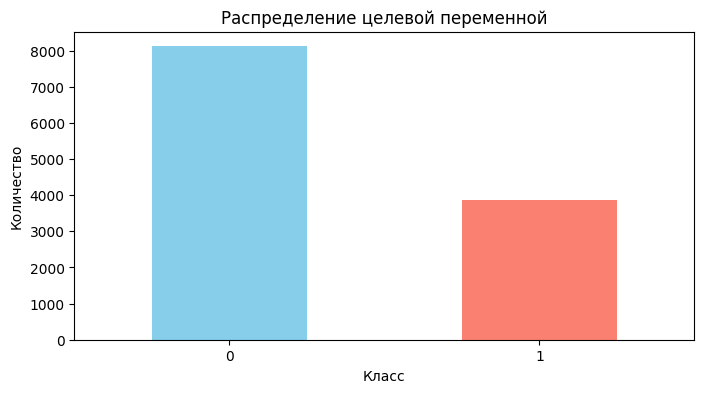

In [8]:
#Визуализация распределения
plt.figure(figsize=(8, 4))
df['target'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Распределение целевой переменной')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.savefig('artifacts/figures/target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [9]:
X = df.drop(['id', 'target'], axis=1)
y=df['target']
feature_names = X.columns.tolist()

print(f"Количество признаков: {len(feature_names)}")
print(f"Признаки: {feature_names}")

Количество признаков: 28
Признаки: ['num01', 'num02', 'num03', 'num04', 'num05', 'num06', 'num07', 'num08', 'num09', 'num10', 'num11', 'num12', 'num13', 'num14', 'num15', 'num16', 'num17', 'num18', 'num19', 'num20', 'num21', 'num22', 'num23', 'num24', 'cat_contract', 'cat_region', 'cat_payment', 'tenure_months']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=RANDOM_STATE, stratify=y)

print(f"\nРазмер train: {X_train.shape}")
print(f"Размер test: {X_test.shape}")

print("Пояснение:")
print("1. random_state=42 обеспечивает воспроизводимость результатов")
print("2. stratify=y сохраняет распределение классов в train и test")
print("3. test_size=0.25 - разумный компромисс между обучением и оценкой")


Размер train: (9000, 28)
Размер test: (3000, 28)
Пояснение:
1. random_state=42 обеспечивает воспроизводимость результатов
2. stratify=y сохраняет распределение классов в train и test
3. test_size=0.25 - разумный компромисс между обучением и оценкой


In [11]:
def evaluate_model(model, X_test, y_test, model_name = "Model"):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None
    
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
    }

    if y_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_test, y_proba)

    print(f"{model_name} - метрики на тесте:")
    for metric, value in metrics.items():
        print(f"{metric}:{value:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

    return metrics

dummy_clf = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_clf.fit(X_train, y_train)
dummy_metrics = evaluate_model(dummy_clf, X_test, y_test, "DummyClassifier")

print("\nИнтерпретация:")
print("DummyClassifier всегда предсказывает самый частый класс (0).")
print("Это дает accuracy = доле класса 0, но бесполезен на практике.")

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)
lr_metrics = evaluate_model(lr_pipeline, X_test, y_test, "LogisticRegression")

print("\nИнтерпретация:")
print("LogisticRegression - линейная модель, хороший baseline.")
print("Уже значительно лучше Dummy, показывает осмысленные предсказания.")

DummyClassifier - метрики на тесте:
accuracy:0.6767
f1:0.0000
roc_auc:0.5000
Confusion Matrix:
[[2030    0]
 [ 970    0]]

Интерпретация:
DummyClassifier всегда предсказывает самый частый класс (0).
Это дает accuracy = доле класса 0, но бесполезен на практике.
LogisticRegression - метрики на тесте:
accuracy:0.8297
f1:0.7147
roc_auc:0.8789
Confusion Matrix:
[[1849  181]
 [ 330  640]]

Интерпретация:
LogisticRegression - линейная модель, хороший baseline.
Уже значительно лучше Dummy, показывает осмысленные предсказания.


In [12]:
print("MODEL 1: DecisionTreeClassifier")

#начнем с простого дерева без ограничений
tree_simple = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_simple.fit(X_train, y_train)

print("Дерево без ограничений:")
tree_simple_metrisc = evaluate_model(tree_simple, X_test, y_test, "Simple Tree")
print(f"Глубина дерева: {tree_simple.get_depth()}")
print(f"Количество листьев: {tree_simple.get_n_leaves()}")

tree_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

tree_clf = DecisionTreeClassifier(random_state=RANDOM_STATE)

tree_grid = GridSearchCV(
    tree_clf,
    tree_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

tree_grid.fit(X_train, y_train)

print(f"\nЛучшие параметры: {tree_grid.best_params_}")
print(f"Лучший CV ROC-AUC: {tree_grid.best_score_:.4f}")

tree_best = tree_grid.best_estimator_
tree_metrics = evaluate_model(tree_best, X_test, y_test, "Decission Tree")

tree_search_summary = {
    'best_params': str(tree_grid.best_params_),
    'best_cv_score': float(tree_grid.best_score_),
    'best_model': 'DecisionTreeClassifier'
}

MODEL 1: DecisionTreeClassifier
Дерево без ограничений:
Simple Tree - метрики на тесте:
accuracy:0.8567
f1:0.7767
roc_auc:0.8343
Confusion Matrix:
[[1822  208]
 [ 222  748]]
Глубина дерева: 24
Количество листьев: 641
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Лучшие параметры: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 10}
Лучший CV ROC-AUC: 0.9037
Decission Tree - метрики на тесте:
accuracy:0.8683
f1:0.7749
roc_auc:0.9053
Confusion Matrix:
[[1925  105]
 [ 290  680]]


In [13]:
print("MODEL 2: RandomForestClassifier")

rf_simple = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100)
rf_simple.fit(X_train, y_train)

rf_simple_metrics = evaluate_model(rf_simple, X_test, y_test, "Simple RandomForest")

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_clf = RandomForestClassifier(random_state=42)

rf_grid = GridSearchCV(
    rf_clf,
    rf_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print(f"\nЛучшие параметры: {rf_grid.best_params_}")
print(f"Лучший CV ROC-AUC: {rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_
rf_metrics = evaluate_model(rf_best, X_test, y_test, "RandomForest")

rf_search_summary = {
    'best_params': str(rf_grid.best_params_),
    'best_cv_score': float(rf_grid.best_score_),
    'best_model': 'RandomForestClassifier'
}

MODEL 2: RandomForestClassifier
Simple RandomForest - метрики на тесте:
accuracy:0.9307
f1:0.8878
roc_auc:0.9697
Confusion Matrix:
[[1969   61]
 [ 147  823]]
Fitting 5 folds for each of 162 candidates, totalling 810 fits

Лучшие параметры: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Лучший CV ROC-AUC: 0.9687
RandomForest - метрики на тесте:
accuracy:0.9333
f1:0.8919
roc_auc:0.9695
Confusion Matrix:
[[1975   55]
 [ 145  825]]


In [14]:
gb_simple = GradientBoostingClassifier(random_state=RANDOM_STATE, n_estimators=100)
gb_simple.fit(X_train, y_train)

gb_simple_metrics = evaluate_model(gb_simple, X_test, y_test, "Simple GradientBoosting")

gb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

gb_clf = GradientBoostingClassifier(random_state=42)

gb_grid = GridSearchCV(
    gb_clf,
    gb_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print(f"\nЛучшие параметры: {gb_grid.best_params_}")
print(f"Лучший CV ROC-AUC: {gb_grid.best_score_:.4f}")

gb_best = gb_grid.best_estimator_
gb_metrics = evaluate_model(gb_best, X_test, y_test, "GradientBoosting")

gb_search_summary = {
    'best_params': str(gb_grid.best_params_),
    'best_cv_score': float(gb_grid.best_score_),
    'best_model': 'GradientBoostingClassifier'
}

Simple GradientBoosting - метрики на тесте:
accuracy:0.9063
f1:0.8447
roc_auc:0.9582
Confusion Matrix:
[[1955   75]
 [ 206  764]]
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Лучший CV ROC-AUC: 0.9727
GradientBoosting - метрики на тесте:
accuracy:0.9400
f1:0.9045
roc_auc:0.9755
Confusion Matrix:
[[1968   62]
 [ 118  852]]


Сводная таблица метрик всех моделей:
                    accuracy        f1   roc_auc
DummyClassifier     0.676667  0.000000  0.500000
LogisticRegression  0.829667  0.714685  0.878909
DecisionTree        0.868333  0.774929  0.905332
RandomForest        0.933333  0.891892  0.969459
GradientBoosting    0.940000  0.904459  0.975467


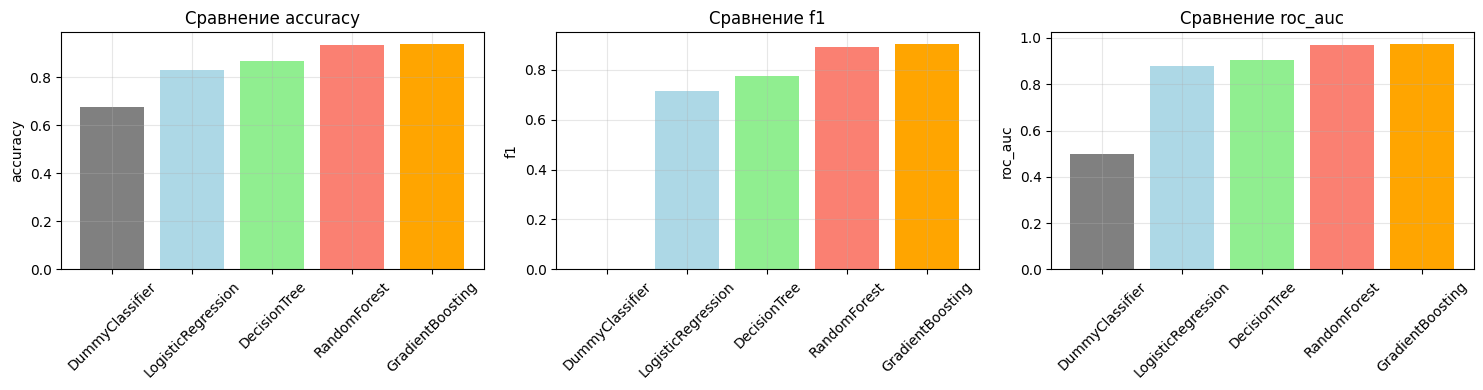

ROC-кривые моделей:


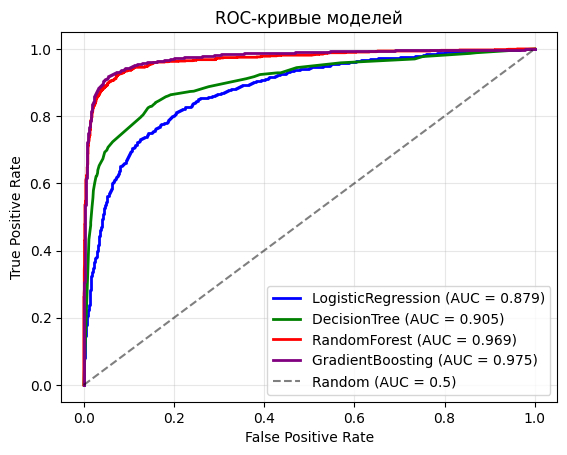

Confusion Matrix для лучшей модели:


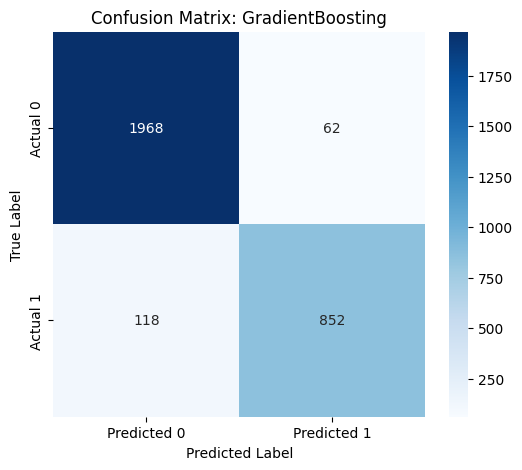


Лучшая модель: GradientBoosting
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      2030
           1       0.93      0.88      0.90       970

    accuracy                           0.94      3000
   macro avg       0.94      0.92      0.93      3000
weighted avg       0.94      0.94      0.94      3000



In [20]:
all_metrics = {
    'DummyClassifier': dummy_metrics,
    'LogisticRegression': lr_metrics,
    'DecisionTree': tree_metrics,
    'RandomForest': rf_metrics,
    'GradientBoosting': gb_metrics
}

metrics_df = pd.DataFrame(all_metrics).T
print("Сводная таблица метрик всех моделей:")
metrics_df.to_csv('artifacts/metrics_summary.csv', index=False, encoding='utf-8-sig') 
print(metrics_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics_to_plot = ['accuracy', 'f1', 'roc_auc']
for idx, metric in enumerate(metrics_to_plot):
    axes[idx].bar(metrics_df.index, metrics_df[metric], color=['gray', 'lightblue', 'lightgreen', 'salmon', 'orange'])
    axes[idx].set_title(f'Сравнение {metric}')
    axes[idx].set_ylabel(metric)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/models_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("ROC-кривые моделей:")
models = [
    (lr_pipeline, 'LogisticRegression', 'blue'),
    (tree_best, 'DecisionTree', 'green'),
    (rf_best, 'RandomForest', 'red'),
    (gb_best, 'GradientBoosting', 'purple')
]

for model, name, color in models:
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)', alpha=0.5)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые моделей')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('artifacts/figures/roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

print("Confusion Matrix для лучшей модели:")
best_model_name = metrics_df['roc_auc'].idxmax()
if best_model_name == 'DummyClassifier':
    best_model_name = metrics_df['roc_auc'][metrics_df.index != 'DummyClassifier'].idxmax()

best_model_dict = {
    'LogisticRegression': lr_pipeline,
    'DecisionTree': tree_best,
    'RandomForest': rf_best,
    'GradientBoosting': gb_best
}

best_model = best_model_dict[best_model_name]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title(f'Confusion Matrix: {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('artifacts/figures/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nЛучшая модель: {best_model_name}")
print(classification_report(y_test, y_pred_best))

Permutation Importance для лучшей модели:


C:\Users\varva\AppData\Local\Temp\ipykernel_4368\2902736222.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx[:15]].T,


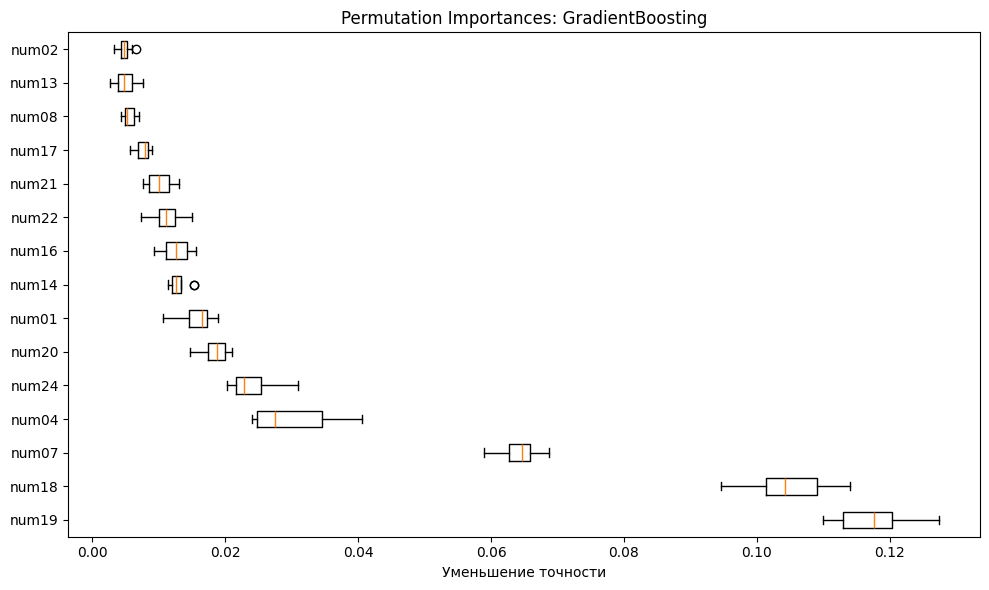


Топ-10 наиболее важных признаков:
num19: 0.1172 +/- 0.0052
num18: 0.1047 +/- 0.0055
num07: 0.0643 +/- 0.0027
num04: 0.0298 +/- 0.0056
num24: 0.0238 +/- 0.0030
num20: 0.0185 +/- 0.0018
num01: 0.0159 +/- 0.0023
num14: 0.0130 +/- 0.0013
num16: 0.0126 +/- 0.0020
num22: 0.0110 +/- 0.0024

Интерпретация:
1. Признаки с наибольшей важностью сильнее всего влияют на предсказания модели
2. Если 'перемешать' значения важного признака, качество модели ухудшится
3. Это помогает понять, на что модель 'смотрит' при принятии решений


In [21]:
print("Permutation Importance для лучшей модели:")

result = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10,  # количество перестановок
    random_state=42,
    n_jobs=-1
)

sorted_idx = result.importances_mean.argsort()[::-1]

# Визуализация top-15 признаков
plt.figure(figsize=(10, 6))
plt.boxplot(result.importances[sorted_idx[:15]].T,
            vert=False, labels=X.columns[sorted_idx[:15]])
plt.title(f"Permutation Importances: {best_model_name}")
plt.xlabel("Уменьшение точности")
plt.tight_layout()
plt.savefig('artifacts/figures/permutation_importance.png', dpi=100, bbox_inches='tight')
plt.show()

# Выводим топ-10 признаков
print("\nТоп-10 наиболее важных признаков:")
for i in sorted_idx[:10]:
    print(f"{X.columns[i]}: {result.importances_mean[i]:.4f} +/- {result.importances_std[i]:.4f}")

print("\nИнтерпретация:")
print("1. Признаки с наибольшей важностью сильнее всего влияют на предсказания модели")
print("2. Если 'перемешать' значения важного признака, качество модели ухудшится")
print("3. Это помогает понять, на что модель 'смотрит' при принятии решений")

In [22]:
metrics_dict = {}
for model_name, metrics in all_metrics.items():
    metrics_dict[model_name] = {k: float(v) for k, v in metrics.items()}

with open('artifacts/metrics_test.json', 'w') as f:
    json.dump(metrics_dict, f, indent=4)

search_summaries = {
    'DecisionTree': tree_search_summary,
    'RandomForest': rf_search_summary,
    'GradientBoosting': gb_search_summary
}

with open('artifacts/search_summaries.json', 'w') as f:
    json.dump(search_summaries, f, indent=4)

joblib.dump(best_model, 'artifacts/best_model.joblib')

best_model_meta = {
    'model_name': best_model_name,
    'best_params': str(best_model.get_params()) if hasattr(best_model, 'get_params') else 'N/A',
    'test_metrics': metrics_dict[best_model_name],
    'features': X.columns.tolist(),
    'dataset': 'S06-hw-dataset-01.csv'
}

with open('artifacts/best_model_meta.json', 'w') as f:
    json.dump(best_model_meta, f, indent=4)